# SOB4ES - RegressorChain (Random Forest base)
### CRISP-ML(Q) - Fase 3 y 4: Desarrollo y evaluacion de los modelos

Este notebook implementa un **RegressorChain** usando Random Forest como modelo base.

La idea es encadenar las predicciones: el modelo primero predice el target 1, luego usa esa prediccion junto a las variables originales para predecir el target 2, y asi sucesivamente. Esto introduce correlacion real entre targets: cada prediccion tiene acceso a las predicciones anteriores en la cadena.

El problema del encadenamiento simple es que los targets al principio de la cadena tienen menos informacion que los del final. Para compensarlo se usa un **ensemble de cadenas** donde cada cadena usa un orden diferente y aleatorio de los targets. Al promediar los resultados, los errores acumulados por el orden se cancelan entre si.

**Datasets utilizados:**
- `train.csv` - Entrenamiento (70 %, estratificado por pais)
- `test.csv`  - Tuning / validacion cruzada (15 %)
- `eval.csv`  - Evaluacion final imparcial (15 %)

**Estructura del notebook:**
1. Configuracion
2. Carga de datos
3. Tuning del modelo base
4. Validacion cruzada
5. Analisis de la cadena: importancia de variables y orden
6. Entrenamiento de produccion (ensemble de cadenas)
7. Evaluacion final

---
## 1. Configuracion del entorno


In [1]:
import os
import time
import warnings
import joblib
import pandas as pd
import numpy as np
from pathlib import Path
import itertools

from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import RegressorChain
from sklearn.model_selection import RandomizedSearchCV, cross_validate, RepeatedKFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import shap

warnings.filterwarnings('ignore')

DATA_DIR   = 'input/'
MODELS_DIR = 'output/models/chain/'
Path(MODELS_DIR).mkdir(parents=True, exist_ok=True)

N_CHAINS = 10  # numero de cadenas en el ensemble; mas cadenas = mas estable pero mas lento

TARGETS = [
    # Shannon diversity index
    'nematode_shannon_z',
    'macro_shannon_z',
    'earthworm_shannon_z',
    'orib_shannon_z',
    'meso_shannon_z',
    'coll_shannon_z',
    'bac_shannon_z',
    'fun_shannon_z',
    'euk_shannon_z',
    'oomy_shannon_z',
    'cerc_shannon_z',
    # Richness
    'macro_order_richness_z',
    'earthworm_richness_z',
    'orib_species_richness_z',
    'meso_species_richness_z',
    'coll_species_richness_z',
    'bac_asv_richness_z',
    'fun_asv_richness_z',
    'euk_asv_richness_z',
    'oomy_asv_richness_z',
    'cerc_asv_richness_z'
]


FEATURES_AUTORIZADAS = [
    'total_plant_cover_z',
    'clay_content_z',
    'silt_content_z',
    'sand_content_z',
    'aggregate_stability_z',
    'bulk_density_z',
    'soil_moisture_z',
    'as_z',
    'cu_z',
    'k_z',
    'mo_z',
    'ni_z',
    'p_z',
    'pb_z',
    'zn_z',
    'soil_ph_z',
    'plot_total_organic_c_z',
    'plot_total_n_z',
    'gee_temp_media_C_z',
    'gee_humedad_rel_pct_z',
    'gee_ndvi_verano_z',
    'dem_elevacion_m_z',
    'dem_pendiente_deg_z',
    'dem_orientacion_deg_z',
    'eu_clay_content_z',
    'eu_sand_content_z',
    'eu_silt_content_z',
    'eu_water_holding_capacity_z',
    'eu_cn_ratio_z',
    'eu_p_z',
    'eu_ph_z',
    'eu_as_z',
    'eu_organic_carbon_octop_z',
    'eu_zn_z'
]


print('Librerias y variables cargadas.')


# Paleta de colores unificada
PALETTE = {
    'blue':         '#7FA6C9',
    'blue_light':   '#AAD0F1',
    'green':        '#7FC8A9',
    'green_light':  '#BEE6D3',
    'purple':       '#A98FC7',
    'purple_light': '#D6C7EA',
    'gray':         '#9B9B9B',
    'gray_dark':    '#5C5C5C',
}

# Secuencia ciclica para graficos con N series/categorias (N puede superar 6)
PALETTE_CYCLE = [PALETTE['blue'], PALETTE['green'], PALETTE['purple'],
                 PALETTE['blue_light'], PALETTE['green_light'], PALETTE['purple_light']]

def palette_cycle(n):
    """Devuelve una lista de n colores repitiendo PALETTE_CYCLE si hace falta."""
    return list(itertools.islice(itertools.cycle(PALETTE_CYCLE), n))

# Colormap secuencial (blanco -> azul -> morado) para heatmaps/matrices de confusion
PALETTE_CMAP = LinearSegmentedColormap.from_list(
    'sob4es_palette', ['#FFFFFF', PALETTE['purple_light'], PALETTE['purple']]
)

Librerias y variables cargadas.


## 2. Carga de datos

Se cargan los tres datasets pre-generados (division 70/15/15, estratificada por pais).

| Archivo    | Uso                                      | Filas aprox. |
|------------|------------------------------------------|--------------|
| `train.csv`| Ajuste del modelo                        | 299          |
| `test.csv` | Tuning / validacion cruzada              | 64           |
| `eval.csv` | Evaluacion final imparcial               | 65           |

El dataset `eval.csv` no se utiliza hasta la seccion 7.

In [2]:
def cargar_csv(ruta, nombre):
    if not os.path.exists(ruta):
        raise FileNotFoundError(f'No se encontro: {ruta}')
    try:
        df = pd.read_csv(ruta, sep=',')
        if len(df.columns) < 5:
            df = pd.read_csv(ruta, sep=';')
    except Exception:
        df = pd.read_csv(ruta, sep=';')
    print(f'  {nombre}: {df.shape[0]} filas x {df.shape[1]} columnas')
    return df

print('Cargando datasets...')
df_train = cargar_csv(os.path.join(DATA_DIR, 'train.csv'), 'train.csv')
df_test  = cargar_csv(os.path.join(DATA_DIR, 'test.csv'),  'test.csv')
df_eval  = cargar_csv(os.path.join(DATA_DIR, 'eval.csv'),  'eval.csv')

X_train = df_train[FEATURES_AUTORIZADAS]
X_test  = df_test[FEATURES_AUTORIZADAS]
X_eval  = df_eval[FEATURES_AUTORIZADAS]

# y es una matriz 2D (n_muestras x n_targets) para todos los modelos de esta fase
y_train = df_train[TARGETS]
y_test  = df_test[TARGETS]
y_eval  = df_eval[TARGETS]

print(f'\nDatasets cargados.')
print(f'X_train: {X_train.shape}  |  y_train: {y_train.shape}')
print(f'X_eval:  {X_eval.shape}   |  y_eval:  {y_eval.shape}')


Cargando datasets...
  train.csv: 299 filas x 71 columnas
  test.csv: 64 filas x 71 columnas
  eval.csv: 65 filas x 71 columnas

Datasets cargados.
X_train: (299, 34)  |  y_train: (299, 21)
X_eval:  (65, 34)   |  y_eval:  (65, 21)


## 3. Tuning del modelo base

`RegressorChain` encapsula un modelo base que se replica una vez por target. El tuning se hace sobre ese modelo base (Random Forest individual) usando un unico target de referencia. Los parametros optimos se usaran para construir cada cadena del ensemble.

Nota: el tuning del modelo base es suficiente porque `RegressorChain` no tiene hiperparametros propios mas alla del orden de la cadena, que se aleatoriza en produccion.

In [3]:
print('Iniciando busqueda de hiperparametros del modelo base...')
print('Este proceso puede tardar varios minutos.\n')

# Espacio de busqueda ampliado
param_grid_frenado = {
    'n_estimators': [150, 300],
    'max_depth': [8, 12, 15],
    'min_samples_split': [10, 15, 20],
    'min_samples_leaf': [4, 6, 8],
    'max_features': ['sqrt', 0.2, 0.3],
    'bootstrap': [True],
    'max_samples': [0.7, 0.8],
    'criterion': ['squared_error', 'absolute_error']
}

referencias = {
    'earthworm_shannon_z':  y_train['earthworm_shannon_z'].values,
    'earthworm_richness_z': y_train['earthworm_richness_z'].values,
}

resultados_tuning = {}
start_total = time.time()

for nombre_target, y_prueba in referencias.items():
    print(f'Buscando hiperparametros para: {nombre_target}')
    buscador = RandomizedSearchCV(
        estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
        param_distributions=param_grid,
        n_iter=50, 
        scoring='r2', 
        cv=5,
        verbose=1, 
        random_state=42, 
        n_jobs=-1
    )

    start_tune = time.time()
    buscador.fit(X_train, y_prueba)
    elapsed = (time.time() - start_tune) / 60

    resultados_tuning[nombre_target] = {
        'params': buscador.best_params_,
        'r2':     buscador.best_score_,
    }
    print(f'  R2: {buscador.best_score_:.4f}  |  tiempo: {elapsed:.1f} min')
    print(f'  Params: {buscador.best_params_}\n')

print(f'Busqueda de hiperparametros completada en {(time.time() - start_total)/60:.1f} minutos.\n')


# Consenso de hiperparametros

params_s = resultados_tuning['earthworm_shannon_z']['params']
params_r = resultados_tuning['earthworm_richness_z']['params']
r2_s     = resultados_tuning['earthworm_shannon_z']['r2']
r2_r     = resultados_tuning['earthworm_richness_z']['r2']

# Pesos proporcionales al R2 de cada target
suma_r2 = r2_s + r2_r
if suma_r2 <= 0:
    w_s, w_r = 0.5, 0.5
else:
    w_s = r2_s / suma_r2
    w_r = r2_r / suma_r2

print('Calculando consenso de hiperparametros...')
print(f'  Peso earthworm_shannon_z  : {w_s:.3f}')
print(f'  Peso earthworm_richness_z : {w_r:.3f}')

# El mejor modelo hereda los parametros categoricos/mixtos
mejor_params = params_s if r2_s >= r2_r else params_r

# 1. Parametros Categoricos/Mixtos (Ganador por R2)
criterion_consenso    = mejor_params['criterion']
bootstrap_consenso    = mejor_params['bootstrap']
max_features_consenso = mejor_params['max_features']
max_depth_consenso    = mejor_params['max_depth']
max_samples_consenso  = mejor_params['max_samples']

# 2. Parametros Numericos (Media ponderada por R2)
n_estimators_consenso      = int(round(w_s * params_s['n_estimators'] + w_r * params_r['n_estimators']))
min_samples_split_consenso = int(round(w_s * params_s['min_samples_split'] + w_r * params_r['min_samples_split']))
min_samples_leaf_consenso  = int(round(w_s * params_s['min_samples_leaf'] + w_r * params_r['min_samples_leaf']))

# Construimos el diccionario base final
BASE_PARAMS = {
    'n_estimators':      n_estimators_consenso,
    'max_depth':         max_depth_consenso,
    'min_samples_split': min_samples_split_consenso,
    'min_samples_leaf':  min_samples_leaf_consenso,
    'max_features':      max_features_consenso,
    'bootstrap':         bootstrap_consenso,
    'max_samples':       max_samples_consenso,
    'criterion':         criterion_consenso,
    'random_state':      42,
    'n_jobs':            -1
}

print('\nHiperparametros consenso finales (Modelo Base):')
for k, v in BASE_PARAMS.items():
    print(f'  {k}: {v}')

# Grafico: R2 de tuning por target de referencia
fig, ax = plt.subplots(figsize=(6, 3.5))
_bars = ax.barh(
    list(resultados_tuning.keys()),
    [v['r2'] for v in resultados_tuning.values()],
    color=[PALETTE['green'], PALETTE['purple']],
    edgecolor='white', height=0.5
)
ax.bar_label(_bars, fmt='{:.3f}', padding=4, fontsize=9)
max_r2 = max(v['r2'] for v in resultados_tuning.values())
ax.set_xlim(0, max_r2 * 1.18 if max_r2 > 0 else 1.0)
ax.set_xlabel('R2 (CV 5-fold, X_train)')
ax.set_title('Tuning - Mejor R2 por target (Modelo Base Cadena)', fontsize=12)
ax.axvline(0, color=PALETTE['gray'], linewidth=0.8)
plt.tight_layout()
plt.show()

Iniciando busqueda de hiperparametros del modelo base...
Este proceso puede tardar varios minutos.

Buscando hiperparametros para: earthworm_shannon_z


NameError: name 'param_grid' is not defined

## 4. Validacion cruzada

Se evalua la robustez de una cadena unica (orden por defecto) con validacion cruzada repetida (5 pliegues x 3 repeticiones) sobre `X_train`. El ensemble de cadenas aleatorias que se entrena en produccion sera mas robusto que esta cadena unica, por lo que estos resultados son una estimacion conservadora del rendimiento final.

In [ ]:
print('Validacion cruzada (cadena unica, orden por defecto)...\n')

cv_splitter = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)
metricas    = ['r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_error']

# Cadena unica para validacion: order=None usa el orden original de TARGETS
cadena_cv = RegressorChain(RandomForestRegressor(**BASE_PARAMS), order=None)

print('-' * 65)
print('Target: MULTI-OUTPUT (Cadena unica, orden por defecto)')
print('-' * 65)

resultados = cross_validate(
    estimator=cadena_cv,
    X=X_train, 
    y=y_train,
    cv=cv_splitter,
    scoring=metricas,
    return_train_score=True
)

r2_train = np.mean(resultados['train_r2'])
r2_cv    = np.mean(resultados['test_r2'])
r2_std   = np.std(resultados['test_r2'])
rmse_cv  = np.mean(-resultados['test_neg_root_mean_squared_error'])
mae_cv   = np.mean(-resultados['test_neg_mean_absolute_error'])

print(f'  Train R2          : {r2_train:.4f}')
print(f'  Validacion R2 (CV): {r2_cv:.4f} +/- {r2_std:.4f}')
print(f'  RMSE global       : {rmse_cv:.4f}')
print(f'  MAE global        : {mae_cv:.4f}')

diferencia = r2_train - r2_cv
if diferencia > 0.15:
    print(f'  Aviso: diferencia train/val = {diferencia:.4f}. Posible sobreajuste.\n')
else:
    print(f'  Diferencia train/val = {diferencia:.4f}. El modelo generaliza correctamente.\n')

# R2 individual por target (entrenando sobre todo X_train)
cadena_cv.fit(X_train, y_train)
y_pred_train = cadena_cv.predict(X_train)

print('  R2 individual por target (Evaluado en train):')
print('-' * 65)
for i, t in enumerate(TARGETS):
    # Aseguramos compatibilidad si y_train es un DataFrame de Pandas
    y_true_col = y_train.iloc[:, i] if hasattr(y_train, 'iloc') else y_train[:, i]
    r2 = r2_score(y_true_col, y_pred_train[:, i])
    print(f'    {t:30} {r2:.4f}')
print()

Validacion cruzada (cadena unica, orden por defecto)...

-----------------------------------------------------------------
Target: MULTI-OUTPUT (Cadena unica, orden por defecto)
-----------------------------------------------------------------
  Train R2          : 0.7023
  Validacion R2 (CV): 0.1705 +/- 0.0255
  RMSE global       : 0.8895
  MAE global        : 0.6661
  Aviso: diferencia train/val = 0.5318. Posible sobreajuste.

  R2 individual por target (Evaluado en train):
-----------------------------------------------------------------
    nematode_shannon_z             0.7949
    macro_shannon_z                0.8100
    earthworm_shannon_z            0.8758
    orib_shannon_z                 0.7571
    meso_shannon_z                 0.6680
    coll_shannon_z                 0.7590
    bac_shannon_z                  0.5880
    fun_shannon_z                  0.6803
    euk_shannon_z                  0.7189
    oomy_shannon_z                 0.7296
    cerc_shannon_z               

## 5. Analisis de la cadena

Se analiza el efecto del orden de la cadena en el rendimiento por target. Los targets al principio de la cadena solo tienen acceso a las variables originales, mientras que los del final tienen ademas las predicciones de todos los anteriores.

Se muestra tambien la importancia de variables del modelo base para el primer target de la cadena, donde no hay predicciones previas disponibles y la dificultad es maxima.

Analisis del efecto del orden en la cadena...

  Posicion en cadena -> target -> R2 (train):
    Posicion  1 | nematode_shannon_z             R2: 0.7949
    Posicion  2 | macro_shannon_z                R2: 0.8100
    Posicion  3 | earthworm_shannon_z            R2: 0.8758
    Posicion  4 | orib_shannon_z                 R2: 0.7571
    Posicion  5 | meso_shannon_z                 R2: 0.6680
    Posicion  6 | coll_shannon_z                 R2: 0.7590
    Posicion  7 | bac_shannon_z                  R2: 0.5880
    Posicion  8 | fun_shannon_z                  R2: 0.6803
    Posicion  9 | euk_shannon_z                  R2: 0.7189
    Posicion 10 | oomy_shannon_z                 R2: 0.7296
    Posicion 11 | cerc_shannon_z                 R2: 0.5441
    Posicion 12 | macro_order_richness_z         R2: 0.7655
    Posicion 13 | earthworm_richness_z           R2: 0.8623
    Posicion 14 | orib_species_richness_z        R2: 0.6139
    Posicion 15 | meso_species_richness_z        R2: 0.5536
    Pos

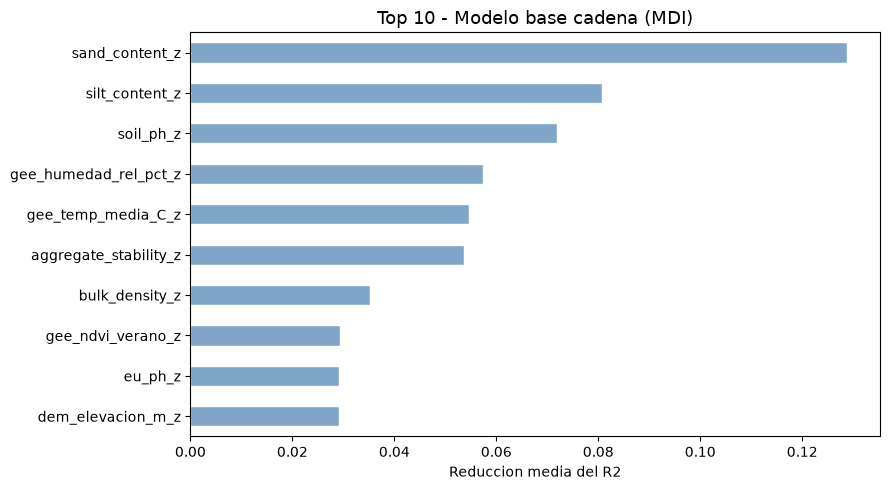

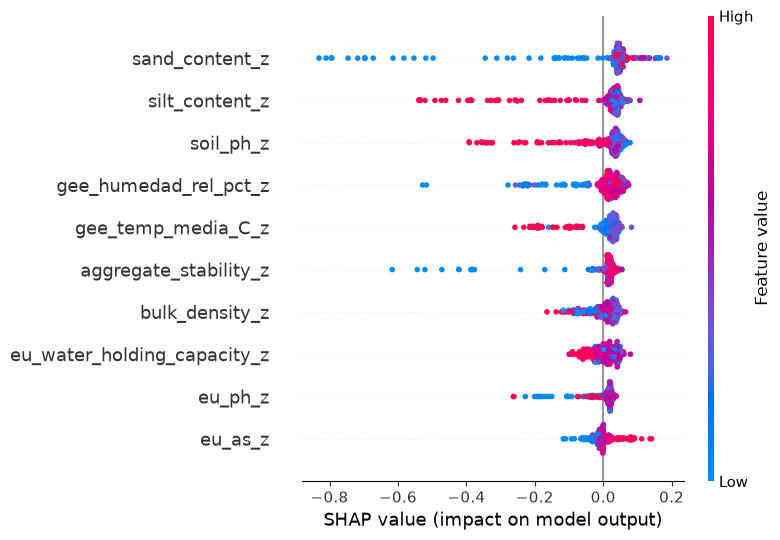

In [ ]:
print('Analisis del efecto del orden en la cadena...\n')

# Comparamos el R2 de cada target segun su posicion en la cadena (orden por defecto)
print('  Posicion en cadena -> target -> R2 (train):')
for i, t in enumerate(TARGETS):
    r2 = r2_score(y_train.iloc[:, i], y_pred_train[:, i])
    print(f'    Posicion {i+1:2d} | {t:30} R2: {r2:.4f}')

# Importancia de variables del modelo base para el primer target
# (el mas dificil: solo tiene las variables originales, sin predicciones previas)
primer_modelo = cadena_cv.estimators_[0]
imp = pd.Series(primer_modelo.feature_importances_, index=FEATURES_AUTORIZADAS)

print('\n  Top 10 variables para el primer target de la cadena:')
print(imp.nlargest(10).round(4).to_string())

# Grafico: barplot permutation importance
fig, ax = plt.subplots(figsize=(9, 5))
imp.nlargest(10).sort_values().plot(kind='barh', ax=ax, color=PALETTE['blue'], edgecolor='white')
ax.set_title('Top 10 - Modelo base cadena (MDI)', fontsize=13)
ax.set_xlabel('Reduccion media del R2')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

# Grafico: SHAP beeswarm - modelo base cadena
explainer   = shap.TreeExplainer(primer_modelo)
shap_values = explainer.shap_values(X_train)

if isinstance(shap_values, list):
    shap_arr = np.mean([np.abs(sv) for sv in shap_values], axis=0)
elif hasattr(shap_values, 'ndim') and shap_values.ndim == 3:
    shap_arr = np.abs(shap_values).mean(axis=2)
else:
    shap_arr = shap_values

shap.summary_plot(shap_arr, X_train, plot_type='dot', max_display=10)

## 6. Entrenamiento de produccion

Se entrenan 10 cadenas con ordenes aleatorios distintos. Cada cadena usa el mismo modelo base (Random Forest con los hiperparametros optimos) pero un orden diferente de los targets. Al promediar las predicciones de todas las cadenas, se compensan los errores de acumulacion que afectan a los targets al principio de cada cadena.

In [ ]:
print(f'Entrenamiento de produccion ({N_CHAINS} cadenas con ordenes aleatorios)...')
print('-' * 70)

global_start = time.time()
ordenes_usados = []

for chain_id in range(N_CHAINS):
    t0 = time.time()

    # Cada cadena usa un orden aleatorio distinto de los 11 targets
    orden = list(np.random.RandomState(42 + chain_id).permutation(len(TARGETS)))
    ordenes_usados.append(orden)

    base_model = RandomForestRegressor(**{**BASE_PARAMS, 'random_state': 42 + chain_id})
    cadena     = RegressorChain(base_model, order=orden)
    cadena.fit(X_train, y_train)

    joblib.dump(cadena, os.path.join(MODELS_DIR, f'chain_{chain_id}.pkl'))
    print(f'  Cadena {chain_id+1:2d}/{N_CHAINS} | orden: {orden} | ({time.time()-t0:.1f}s)')

# Guardamos los ordenes para referencia futura
joblib.dump(ordenes_usados, os.path.join(MODELS_DIR, 'ordenes.pkl'))

print('-' * 70)
print(f'Produccion completada en {(time.time()-global_start)/60:.1f} minutos.')


Entrenamiento de produccion (10 cadenas con ordenes aleatorios)...
----------------------------------------------------------------------
  Cadena  1/10 | orden: [np.int64(0), np.int64(17), np.int64(15), np.int64(1), np.int64(8), np.int64(5), np.int64(11), np.int64(3), np.int64(18), np.int64(16), np.int64(13), np.int64(2), np.int64(9), np.int64(20), np.int64(4), np.int64(12), np.int64(7), np.int64(10), np.int64(14), np.int64(19), np.int64(6)] | (2.8s)
  Cadena  2/10 | orden: [np.int64(20), np.int64(12), np.int64(8), np.int64(5), np.int64(6), np.int64(11), np.int64(10), np.int64(13), np.int64(1), np.int64(9), np.int64(18), np.int64(3), np.int64(19), np.int64(7), np.int64(15), np.int64(14), np.int64(2), np.int64(16), np.int64(17), np.int64(0), np.int64(4)] | (2.8s)
  Cadena  3/10 | orden: [np.int64(15), np.int64(14), np.int64(9), np.int64(2), np.int64(5), np.int64(11), np.int64(18), np.int64(1), np.int64(6), np.int64(12), np.int64(7), np.int64(8), np.int64(10), np.int64(16), np.int64(4),

## 7. Evaluacion final y prueba de funcionamiento

Esta seccion tiene dos partes:

**Evaluacion final**
Se mide por primera vez el rendimiento sobre `eval.csv`. Se muestran metricas globales (promedio sobre los 11 targets) y R2 individual por target.

**Smoke test**
Se verificia que el pipeline funciona de extremo a extremo con 3 filas reales de `eval.csv`.

---
**Como leer el indice Shannon H':**
Cada target es el indice de diversidad de Shannon de un grupo biologico distinto. El valor va de `0.0` (sin diversidad) a `4.0-5.0` (alta diversidad). Un valor tipico en suelos agricolas europeos se situa entre `1.5` y `2.5`.

Evaluacion final sobre eval.csv
------------------------------------------------------------
  R2   global: 0.0901
  RMSE global: 0.9138 puntos de Shannon H'
  MAE  global: 0.6728 puntos de Shannon H'

  R2 por target:
    nematode_shannon_z             0.1659
    macro_shannon_z                0.3408
    earthworm_shannon_z            0.5450
    orib_shannon_z                 0.2478
    meso_shannon_z                 -0.2449
    coll_shannon_z                 -0.6500
    bac_shannon_z                  -0.0096
    fun_shannon_z                  -0.0265
    euk_shannon_z                  0.2065
    oomy_shannon_z                 0.0867
    cerc_shannon_z                 0.0266
    macro_order_richness_z         0.4561
    earthworm_richness_z           0.5895
    orib_species_richness_z        0.2362
    meso_species_richness_z        -0.0650
    coll_species_richness_z        -0.5584
    bac_asv_richness_z             -0.0673
    fun_asv_richness_z             -0.0277
    euk_asv_richn

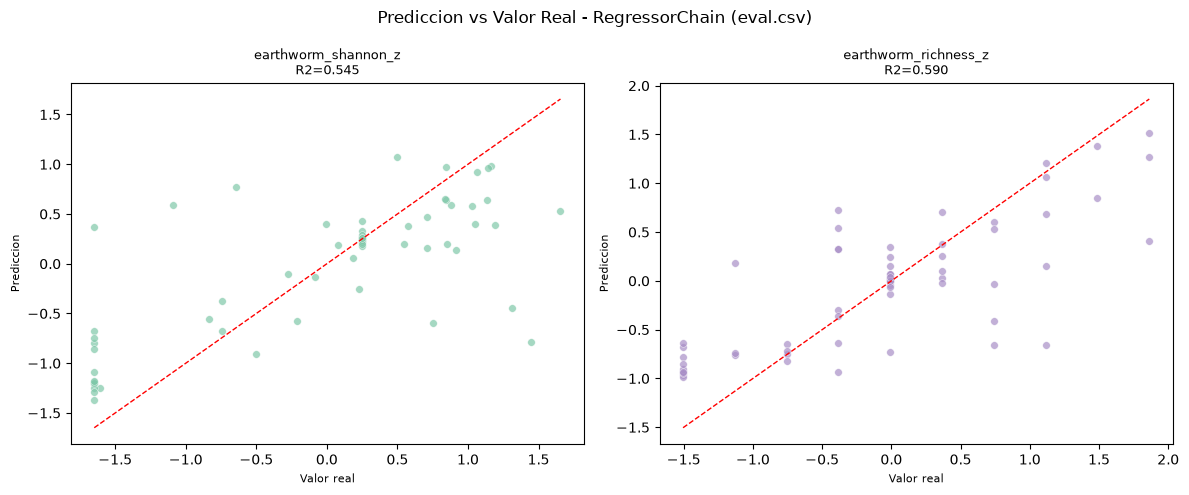

In [ ]:

# Evaluacion final
# Cargamos las N cadenas y promediamos sus predicciones sobre eval.csv.

print('Evaluacion final sobre eval.csv')
print('-' * 60)

preds_eval = []
for chain_id in range(N_CHAINS):
    ruta   = os.path.join(MODELS_DIR, f'chain_{chain_id}.pkl')
    cadena = joblib.load(ruta)
    preds_eval.append(cadena.predict(X_eval))

# Promediamos sobre todas las cadenas: shape (N_CHAINS, n_eval, 11) -> (n_eval, 11)
y_pred_eval = np.mean(preds_eval, axis=0)
y_true_eval = y_eval.values

r2_global   = r2_score(y_true_eval, y_pred_eval, multioutput='uniform_average')
rmse_global = np.sqrt(mean_squared_error(y_true_eval, y_pred_eval, multioutput='uniform_average'))
mae_global  = mean_absolute_error(y_true_eval, y_pred_eval, multioutput='uniform_average')

print(f'  R2   global: {r2_global:.4f}')
print(f'  RMSE global: {rmse_global:.4f} puntos de Shannon H\'')
print(f'  MAE  global: {mae_global:.4f} puntos de Shannon H\'')

print('\n  R2 por target:')
r2_por_target = r2_score(y_true_eval, y_pred_eval, multioutput='raw_values')
for t, r2 in zip(TARGETS, r2_por_target):
    print(f'    {t:30} {r2:.4f}')


# Smoke test con datos reales

print('\nSmoke test - Inferencia con datos reales')
print('-' * 60)

try:
    df_new_data      = X_eval.sample(n=3, random_state=42)
    indices_elegidos = df_new_data.index
    valores_reales   = y_eval.loc[indices_elegidos].values

    votos = []
    for chain_id in range(N_CHAINS):
        ruta   = os.path.join(MODELS_DIR, f'chain_{chain_id}.pkl')
        cadena = joblib.load(ruta)
        pred   = cadena.predict(df_new_data)
        votos.append(pred)
        # pred es una matriz (3 muestras x 11 targets)
        print(f'  Cadena {chain_id+1:2d} | '
              f'Fila {indices_elegidos[0]}: {pred[0, 2]:.4f} | '
              f'Fila {indices_elegidos[1]}: {pred[1, 2]:.4f} | '
              f'Fila {indices_elegidos[2]}: {pred[2, 2]:.4f}  (earthworm_shannon_z)')

    consenso = np.mean(votos, axis=0)
    print('-' * 60)
    print('  Resultados detallados por muestra (earthworm_shannon_z):')
    print('-' * 60)

    idx_earth = TARGETS.index('earthworm_shannon_z')
    for i, idx in enumerate(indices_elegidos):
        pred_val = consenso[i, idx_earth]
        real_val = y_eval.loc[idx, 'earthworm_shannon_z']
        error    = abs(pred_val - real_val)
        print(f'    Fila {idx:<4} | Prediccion: {pred_val:.4f} | '
              f'Valor Real: {real_val:.4f} | Error absoluto: {error:.4f}')

    print('-' * 60)
    print('\nSmoke test superado. El ensemble de cadenas funciona correctamente.')

except Exception as e:
    print(f'Error en el smoke test: {str(e)}')

# Grafico: scatter prediccion vs valor real (targets principales)
_targets_plot = ['earthworm_shannon_z', 'earthworm_richness_z']
_colors_plot  = [PALETTE['green'], PALETTE['purple']]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, tgt, col in zip(axes, _targets_plot, _colors_plot):
    idx_col = TARGETS.index(tgt)
    yp = y_pred_eval[:, idx_col]
    yt = y_true_eval[:, idx_col]
    ax.scatter(yt, yp, alpha=0.7, s=30, color=col, edgecolors='white', linewidths=0.4)
    lim = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    ax.plot(lim, lim, 'r--', linewidth=1)
    ax.set_title(f'{tgt}\nR2={r2_score(yt, yp):.3f}', fontsize=9)
    ax.set_xlabel('Valor real', fontsize=8)
    ax.set_ylabel('Prediccion', fontsize=8)
plt.suptitle('Prediccion vs Valor Real - RegressorChain (eval.csv)', fontsize=12)
plt.tight_layout()
plt.show()